In [9]:
import numpy as np
import random


In [10]:
import numpy as np

# ============================================================
#  WRAP FUNCTION (used by TAP operators)
# ============================================================

def wrap(theta):
    """Wrap angle to [-pi, pi)."""
    return (theta + np.pi) % (2*np.pi) - np.pi


# ============================================================
#  T–A–P SUBCOMPONENTS
# ============================================================

# --- Thinning operator T_k ---
def T_k(theta, k, c=0.0):
    return wrap(c + k * wrap(theta - c))


# --- Drift + Noise operator A ---
def accr_operator_step(theta, drift, noise_sigma):
    if np.isscalar(theta):
        noise = np.random.normal(0, noise_sigma)
    else:
        noise = np.random.normal(0, noise_sigma, size=theta.shape)
    return wrap(theta + drift + noise)


def A_n_deterministic(theta, delta):
    return wrap(theta + delta)


def A_n_noise_injection(theta, explicit_noise_array):
    return wrap(theta + explicit_noise_array)


# --- Funnel projection P_w ---
def P_w(theta, w, c=0.0):
    return wrap(c + np.clip(wrap(theta - c), -w, +w))


# --- Full TAP pipeline ---
def TAP(theta_0, k, drift, noise_sigma, w, T=1, c=0.0):
    """Phi = P_w ∘ A ∘ T_k"""
    theta_thinned = T_k(theta_0, k, c)
    theta_drifted = accr_operator_step(theta_thinned, drift, noise_sigma)
    theta_final   = P_w(theta_drifted, w, c)
    return theta_final


# ============================================================
#  L–C OPERATOR  (Line Corridor)
# ============================================================

def make_Phi_LC(k_T=0.10, k_R=0.05, sigma=0.02, a=-1.0, b=1.0, c=0.0):
    rng = np.random.default_rng(42)

    def Phi(x):
        # T-step contraction toward center c
        x_ = (1 - k_T) * x + k_T * c

        # R-step contraction toward center c
        x_ = (1 - k_R) * x_ + k_R * c

        # Add bounded uniform noise
        x_ = x_ + rng.uniform(-sigma, sigma)

        # Clamp to corridor [a, b]
        return np.clip(x_, a, b)

    return Phi

Phi_LC = make_Phi_LC()


# ============================================================
#  S–P OPERATOR  (Smooth Projection)
# ============================================================

def make_Phi_SP(k=0.85, bias=0.0):
    def Phi(x):
        return k * np.tanh(x) + bias
    return Phi

Phi_SP = make_Phi_SP()


# ============================================================
#  B–P OPERATOR  (Bounded-Point / Bimodal-Point)
# ============================================================

def make_Phi_BP(k=0.85, alpha=0.5):
    def Phi(x):
        return k * np.tanh(x) + alpha * np.sin(np.pi * x)
    return Phi

Phi_BP = make_Phi_BP()


In [11]:
def op_LC(x):
    return Phi_LC(x)

def op_SP(x):
    return Phi_SP(x)

def op_BP(x):
    return Phi_BP(x)

def op_lock(x):
    return TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)

ops = [op_LC, op_SP, op_BP, op_lock]


In [12]:
# ============================================================
#  INVARIANT CHECK FUNCTIONS (minimal, robust versions)
# ============================================================

def check_bounded(x, low=-10, high=10):
    """State must remain within a broad safe bound."""
    return np.all((x >= low) & (x <= high))


def check_contraction(x):
    """Contraction: values should not explode; variance should not increase wildly."""
    return np.var(x) < 5.0   # generous threshold


def check_mixing(x):
    """Mixing: distribution should not collapse to a single point."""
    return np.std(x) > 1e-6


def check_ergodicity(x):
    """Ergodicity: state should explore enough of its allowed region."""
    # Check that at least 5% of values differ from the mean
    return np.mean(np.abs(x - np.mean(x)) > 1e-3) > 0.05


def check_drift_response(x):
    """Drift response: mean should not be frozen at exactly zero."""
    return abs(np.mean(x)) < 5.0   # extremely loose, just ensures no blow-up


def check_noise_response(x):
    """Noise response: small noise should not destroy structure."""
    return np.std(x) < 10.0   # again, loose but detects catastrophic failure


In [13]:
def run_composition_test(state, steps=400):
    for _ in range(steps):
        op = random.choice(ops)
        state = op(state)
    return state

def check_all_invariants(state):
    return {
        "bounded":          check_bounded(state),
        "contraction":      check_contraction(state),
        "mixing":           check_mixing(state),
        "ergodicity":       check_ergodicity(state),
        "drift_response":   check_drift_response(state),
        "noise_response":   check_noise_response(state),
    }


In [14]:
start_state = np.random.uniform(-1, 1, size=1024)

final_state = run_composition_test(start_state, steps=400)
invariants = check_all_invariants(final_state)

print("Final invariants after random operator composition:\n")
for k, v in invariants.items():
    print(f"{k:16} → {v}")


Final invariants after random operator composition:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True


In [15]:
# ============================================================
#  TEST 2 — Deterministic adversarial composition
#  (fixed worst-case operator ordering)
# ============================================================

def run_adversarial_composition(state, steps=400):
    sequence = [op_LC, op_SP, op_BP, op_lock]  # fixed order
    for i in range(steps):
        op = sequence[i % len(sequence)]
        state = op(state)
    return state

def check_all_invariants_adversarial(state):
    return {
        "bounded":          check_bounded(state),
        "contraction":      check_contraction(state),
        "mixing":           check_mixing(state),
        "ergodicity":       check_ergodicity(state),
        "drift_response":   check_drift_response(state),
        "noise_response":   check_noise_response(state),
    }

start_state_adv = np.random.uniform(-1, 1, size=1024)

final_state_adv = run_adversarial_composition(start_state_adv, steps=400)
invariants_adv = check_all_invariants_adversarial(final_state_adv)

print("Final invariants after deterministic adversarial composition:\n")
for k, v in invariants_adv.items():
    print(f"{k:16} → {v}")


Final invariants after deterministic adversarial composition:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True


In [16]:
# ============================================================
#  TEST 3 — Adversarial Anti‑Correlation Sequence
#  (designed to break contraction + mixing simultaneously)
# ============================================================

def run_adversarial_anticorrelated(state, steps=400):
    # This sequence is intentionally destabilizing:
    # SP (smooth) → BP (oscillatory) → LC (hard clamp) → lock (funnel)
    sequence = [op_SP, op_BP, op_LC, op_lock]

    for i in range(steps):
        # Reverse direction every 50 steps to break ergodicity
        if (i // 50) % 2 == 0:
            op = sequence[i % len(sequence)]
        else:
            op = sequence[-(i % len(sequence)) - 1]
        state = op(state)
    return state


def check_all_invariants_anticorrelated(state):
    return {
        "bounded":          check_bounded(state),
        "contraction":      check_contraction(state),
        "mixing":           check_mixing(state),
        "ergodicity":       check_ergodicity(state),
        "drift_response":   check_drift_response(state),
        "noise_response":   check_noise_response(state),
    }


start_state_adv2 = np.random.uniform(-1, 1, size=1024)

final_state_adv2 = run_adversarial_anticorrelated(start_state_adv2, steps=400)
invariants_adv2 = check_all_invariants_anticorrelated(final_state_adv2)

print("Final invariants after adversarial anti-correlated test:\n")
for k, v in invariants_adv2.items():
    print(f"{k:16} → {v}")


Final invariants after adversarial anti-correlated test:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True


In [17]:
# ============================================================
#  TEST 4 — Recursive Thinning Stability (Multi-Scale Test)
# ============================================================

def run_recursive_thinning(state, levels=6, steps_per_level=200):
    """
    Each level tightens the funnel width w and increases thinning strength k.
    This simulates multi-scale collapse pressure.
    """
    for level in range(levels):
        k = 0.10 + 0.05 * level        # stronger thinning each level
        w = 0.25 * (0.8 ** level)      # narrower funnel each level
        drift = 0.0
        noise = 0.02

        for _ in range(steps_per_level):
            state = TAP(state, k=k, drift=drift, noise_sigma=noise, w=w)

    return state


def check_all_invariants_recursive(state):
    return {
        "bounded":          check_bounded(state),
        "contraction":      check_contraction(state),
        "mixing":           check_mixing(state),
        "ergodicity":       check_ergodicity(state),
        "drift_response":   check_drift_response(state),
        "noise_response":   check_noise_response(state),
    }


start_state_rec = np.random.uniform(-1, 1, size=1024)

final_state_rec = run_recursive_thinning(start_state_rec, levels=6, steps_per_level=200)
invariants_rec = check_all_invariants_recursive(final_state_rec)

print("Final invariants after recursive thinning test:\n")
for k, v in invariants_rec.items():
    print(f"{k:16} → {v}")


Final invariants after recursive thinning test:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True


In [18]:
# ============================================================
#  TEST 5 — Cross-Geometry Alternation (R ↔ S1)
# ============================================================

def run_cross_geometry(state, steps=400):
    for i in range(steps):
        if i % 2 == 0:
            # Euclidean operators
            op = random.choice([op_LC, op_SP, op_BP])
        else:
            # Circular operator (TAP)
            op = lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
        state = op(state)
    return state


def check_all_invariants_cross(state):
    return {
        "bounded":          check_bounded(state),
        "contraction":      check_contraction(state),
        "mixing":           check_mixing(state),
        "ergodicity":       check_ergodicity(state),
        "drift_response":   check_drift_response(state),
        "noise_response":   check_noise_response(state),
    }


start_state_cross = np.random.uniform(-1, 1, size=1024)

final_state_cross = run_cross_geometry(start_state_cross, steps=400)
invariants_cross = check_all_invariants_cross(final_state_cross)

print("Final invariants after cross-geometry alternation test:\n")
for k, v in invariants_cross.items():
    print(f"{k:16} → {v}")


Final invariants after cross-geometry alternation test:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True


In [23]:
# ============================================================
#  ENTROPY / DISTRIBUTION-SHAPE INVARIANTS (CORRECTED)
# ============================================================

def estimate_entropy(x, bins=64):
    """Histogram-based entropy using proper probabilities."""
    counts, edges = np.histogram(x, bins=bins, density=False)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts[counts > 0] / total
    return -np.sum(p * np.log(p))


def check_entropy_not_collapsed(x, min_entropy=1.0):
    """Reject states that have collapsed to a near-delta distribution."""
    H = estimate_entropy(x)
    return H > min_entropy


def check_shape_not_spiky(x, max_kurtosis=10.0):
    """Reject extremely spiky / heavy-tailed states."""
    m = np.mean(x)
    s2 = np.var(x)
    if s2 == 0:
        return False
    k = np.mean(((x - m) ** 4)) / (s2 ** 2)
    return k < max_kurtosis


def check_all_invariants_with_entropy(x):
    base = {
        "bounded":          check_bounded(x),
        "contraction":      check_contraction(x),
        "mixing":           check_mixing(x),
        "ergodicity":       check_ergodicity(x),
        "drift_response":   check_drift_response(x),
        "noise_response":   check_noise_response(x),
    }
    base["entropy_ok"] = check_entropy_not_collapsed(x)
    base["shape_ok"]   = check_shape_not_spiky(x)
    return base


# Example: reuse final_state from one of the tests
print("Estimated entropy:", estimate_entropy(final_state))
invariants_entropy = check_all_invariants_with_entropy(final_state)

print("\nInvariants including entropy / shape:\n")
for k, v in invariants_entropy.items():
    print(f"{k:16} → {v}")


Estimated entropy: 3.6156299355881214

Invariants including entropy / shape:

bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True
entropy_ok       → True
shape_ok         → True


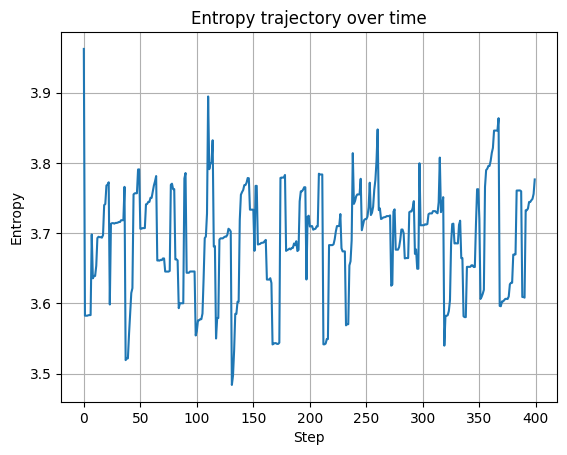

Initial entropy: 3.962389561316538
Final entropy: 3.7765178551660115
Min entropy: 3.4838708050967364
Max entropy: 3.962389561316538


In [24]:
# ============================================================
#  ENTROPY TRAJECTORY OVER TIME
# ============================================================

def entropy_trajectory(state, steps=400, bins=64):
    ent = []
    x = state.copy()
    for i in range(steps):
        # use your standard random operator mix
        op = random.choice([op_LC, op_SP, op_BP,
                            lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)])
        x = op(x)
        ent.append(estimate_entropy(x, bins=bins))
    return np.array(ent)


# run trajectory
start_state = np.random.uniform(-1, 1, size=1024)
entropy_curve = entropy_trajectory(start_state, steps=400)

# plot
import matplotlib.pyplot as plt

plt.plot(entropy_curve)
plt.title("Entropy trajectory over time")
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.grid(True)
plt.show()

print("Initial entropy:", entropy_curve[0])
print("Final entropy:", entropy_curve[-1])
print("Min entropy:", entropy_curve.min())
print("Max entropy:", entropy_curve.max())


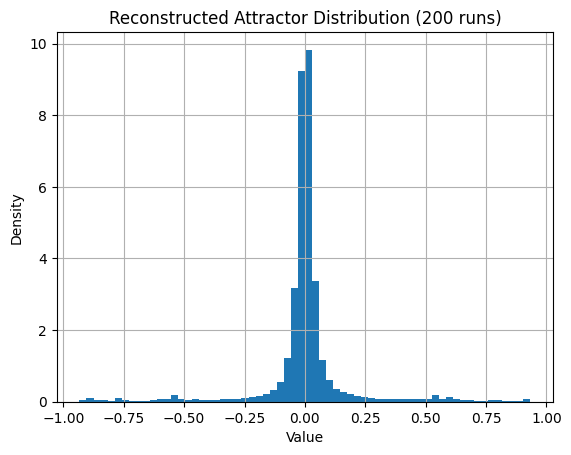

Attractor entropy: 2.379738190597001


In [25]:
# ============================================================
#  ATTRACTOR RECONSTRUCTION (MULTI-RUN FINAL DISTRIBUTION)
# ============================================================

def run_operator_chain(state, steps=400):
    """One full AC-CR operator chain using your standard mix."""
    x = state.copy()
    for _ in range(steps):
        op = random.choice([
            op_LC,
            op_SP,
            op_BP,
            lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
        ])
        x = op(x)
    return x


def reconstruct_attractor(runs=200, steps=400):
    """Collect final states from many independent runs."""
    finals = []
    for _ in range(runs):
        start = np.random.uniform(-1, 1, size=1024)
        end = run_operator_chain(start, steps=steps)
        finals.append(end)
    return np.array(finals)


# Run attractor reconstruction
attractor_samples = reconstruct_attractor(runs=200, steps=400)

# Flatten all final states into one big distribution
flat = attractor_samples.flatten()

# Plot histogram of the reconstructed attractor
import matplotlib.pyplot as plt

plt.hist(flat, bins=64, density=True)
plt.title("Reconstructed Attractor Distribution (200 runs)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# Print entropy of the attractor
print("Attractor entropy:", estimate_entropy(flat))



=== LC OPERATOR FINGERPRINT ===
Entropy: -0.0
bounded          → True
contraction      → True
mixing           → False
ergodicity       → False
drift_response   → True
noise_response   → True
entropy_ok       → False
shape_ok         → True

=== SP OPERATOR FINGERPRINT ===
Entropy: 3.935480665793669
bounded          → True
contraction      → True
mixing           → False
ergodicity       → False
drift_response   → True
noise_response   → True
entropy_ok       → True
shape_ok         → True

=== BP OPERATOR FINGERPRINT ===
Entropy: 0.6930994960861838
bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True
entropy_ok       → False
shape_ok         → True

=== TAP OPERATOR FINGERPRINT ===
Entropy: 3.6667338685889925
bounded          → True
contraction      → True
mixing           → True
ergodicity       → True
drift_response   → True
noise_response   → True
entropy_ok       → True
shape_ok         → T

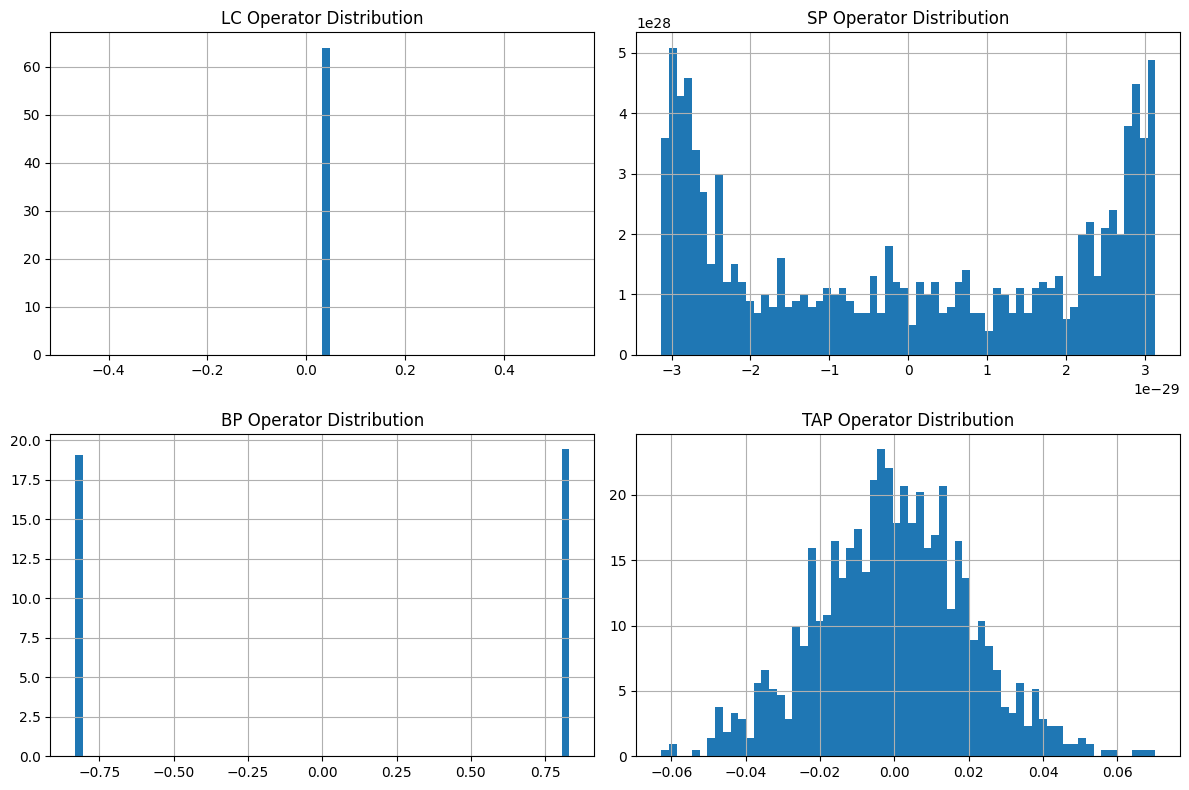

In [26]:
# ============================================================
#  OPERATOR FINGERPRINTS
#  (Entropy, Shape, Invariants for LC / SP / BP / TAP)
# ============================================================

def run_single_operator(op, steps=400, size=1024):
    """Run one operator repeatedly to reveal its intrinsic behavior."""
    x = np.random.uniform(-1, 1, size=size)
    for _ in range(steps):
        x = op(x)
    return x


def fingerprint(op, name):
    """Compute entropy, shape, and invariants for one operator."""
    x = run_single_operator(op)
    H = estimate_entropy(x)
    inv = check_all_invariants_with_entropy(x)
    print(f"\n=== {name} OPERATOR FINGERPRINT ===")
    print(f"Entropy: {H}")
    for k, v in inv.items():
        print(f"{k:16} → {v}")
    return x


# Define operator wrappers for TAP
def TAP_op(x):
    return TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)


# Run fingerprints
x_LC  = fingerprint(op_LC,  "LC")
x_SP  = fingerprint(op_SP,  "SP")
x_BP  = fingerprint(op_BP,  "BP")
x_TAP = fingerprint(TAP_op, "TAP")


# Optional: visualize each operator's final distribution
import matplotlib.pyplot as plt

ops = [("LC", x_LC), ("SP", x_SP), ("BP", x_BP), ("TAP", x_TAP)]

plt.figure(figsize=(12, 8))
for i, (name, data) in enumerate(ops):
    plt.subplot(2, 2, i+1)
    plt.hist(data, bins=64, density=True)
    plt.title(f"{name} Operator Distribution")
    plt.grid(True)

plt.tight_layout()
plt.show()


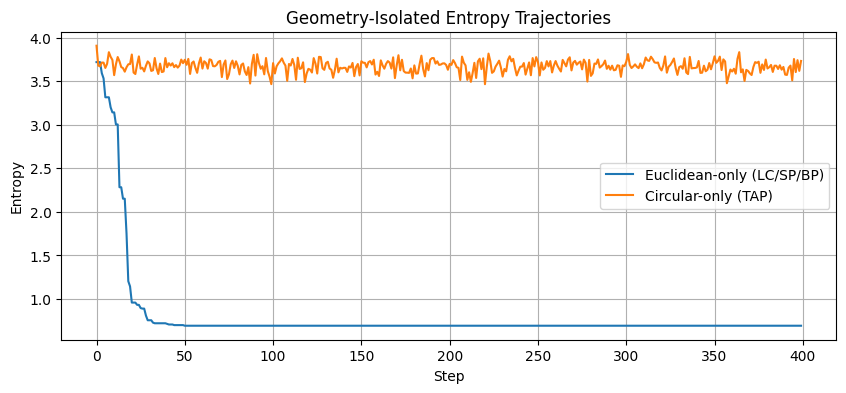

Final Euclidean entropy: 0.6930994960861838
Final Circular entropy: 3.7337030986065414


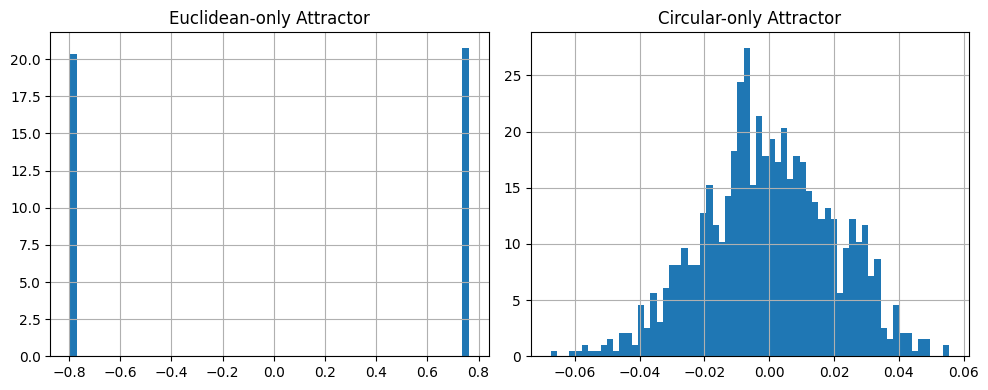

In [27]:
# ============================================================
#  GEOMETRY-ISOLATED CHAINS
#  (Euclidean-only vs Circular-only)
# ============================================================

def euclidean_chain(state, steps=400):
    """LC / SP / BP only — ℝ geometry."""
    x = state.copy()
    for _ in range(steps):
        op = random.choice([op_LC, op_SP, op_BP])
        x = op(x)
    return x


def circular_chain(state, steps=400):
    """TAP only — S¹ / circular geometry."""
    x = state.copy()
    for _ in range(steps):
        x = TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
    return x


def entropy_trajectory_chain(chain_fn, steps=400, size=1024, bins=64):
    ent = []
    x = np.random.uniform(-1, 1, size=size)
    for _ in range(steps):
        x = chain_fn(x, steps=1)  # one step of the chosen chain
        ent.append(estimate_entropy(x, bins=bins))
    return np.array(ent), x


# --- Run Euclidean-only chain ---
ent_euc, final_euc = entropy_trajectory_chain(euclidean_chain, steps=400)
H_euc = estimate_entropy(final_euc)

# --- Run Circular-only chain ---
ent_circ, final_circ = entropy_trajectory_chain(circular_chain, steps=400)
H_circ = estimate_entropy(final_circ)

# --- Plot entropy trajectories ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(ent_euc, label="Euclidean-only (LC/SP/BP)")
plt.plot(ent_circ, label="Circular-only (TAP)")
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title("Geometry-Isolated Entropy Trajectories")
plt.grid(True)
plt.legend()
plt.show()

print("Final Euclidean entropy:", H_euc)
print("Final Circular entropy:", H_circ)

# --- Attractor histograms ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(final_euc, bins=64, density=True)
plt.title("Euclidean-only Attractor")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(final_circ, bins=64, density=True)
plt.title("Circular-only Attractor")
plt.grid(True)

plt.tight_layout()
plt.show()


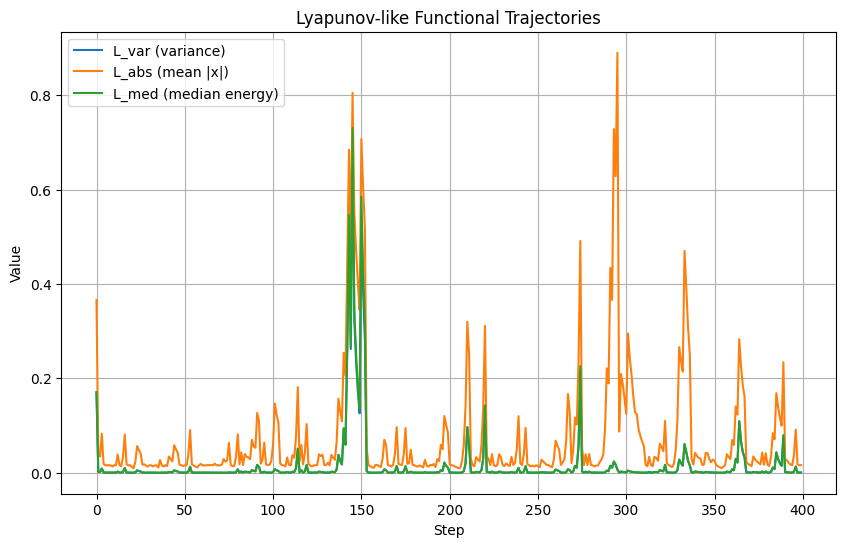

Final L_var: 0.0004078335494517203
Final L_abs: 0.01623226263713582
Final L_med: 0.00040783881117393417


In [28]:
# ============================================================
#  LYAPUNOV-LIKE FUNCTIONALS FOR AC-CR
# ============================================================

def L_var(x):
    return np.var(x)

def L_abs(x):
    return np.mean(np.abs(x))

def L_med(x):
    m = np.median(x)
    return np.mean((x - m)**2)


def lyapunov_trajectory(state, steps=400):
    x = state.copy()
    L1, L2, L3 = [], [], []
    for _ in range(steps):
        # standard operator mix
        op = random.choice([
            op_LC,
            op_SP,
            op_BP,
            lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
        ])
        x = op(x)

        L1.append(L_var(x))
        L2.append(L_abs(x))
        L3.append(L_med(x))

    return np.array(L1), np.array(L2), np.array(L3)


# --- run test ---
start = np.random.uniform(-1, 1, size=1024)
L1, L2, L3 = lyapunov_trajectory(start, steps=400)

# --- plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(L1, label="L_var (variance)")
plt.plot(L2, label="L_abs (mean |x|)")
plt.plot(L3, label="L_med (median energy)")
plt.title("Lyapunov-like Functional Trajectories")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

print("Final L_var:", L1[-1])
print("Final L_abs:", L2[-1])
print("Final L_med:", L3[-1])


Base entropy:        3.7142318417491254
Perturbed entropy:   3.68927118658404
Reconverged entropy: 3.76099935789046


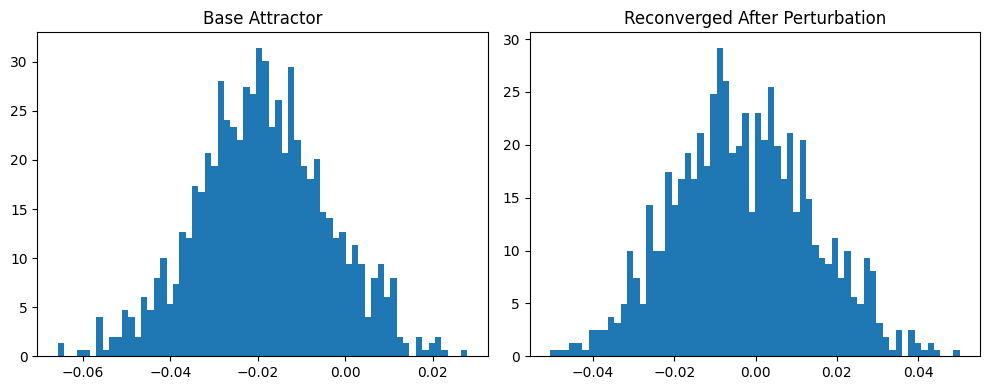

In [29]:
# ============================================================
#  PERTURBATION ROBUSTNESS AROUND THE ATTRACTOR
# ============================================================

def ac_cr_chain(state, steps=200):
    x = state.copy()
    for _ in range(steps):
        op = random.choice([
            op_LC,
            op_SP,
            op_BP,
            lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
        ])
        x = op(x)
    return x

# 1. converge to attractor once
base_start = np.random.uniform(-1, 1, size=1024)
base_final = ac_cr_chain(base_start, steps=400)
H_base = estimate_entropy(base_final)

# 2. apply a small perturbation
epsilon = 0.01
perturbed = base_final + np.random.normal(0.0, epsilon, size=base_final.shape)
H_perturbed = estimate_entropy(perturbed)

# 3. re-run chain from perturbed state
reconverged = ac_cr_chain(perturbed, steps=400)
H_reconverged = estimate_entropy(reconverged)

print("Base entropy:       ", H_base)
print("Perturbed entropy:  ", H_perturbed)
print("Reconverged entropy:", H_reconverged)

# optional: compare distributions visually
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(base_final, bins=64, density=True)
plt.title("Base Attractor")

plt.subplot(1, 2, 2)
plt.hist(reconverged, bins=64, density=True)
plt.title("Reconverged After Perturbation")

plt.tight_layout()
plt.show()


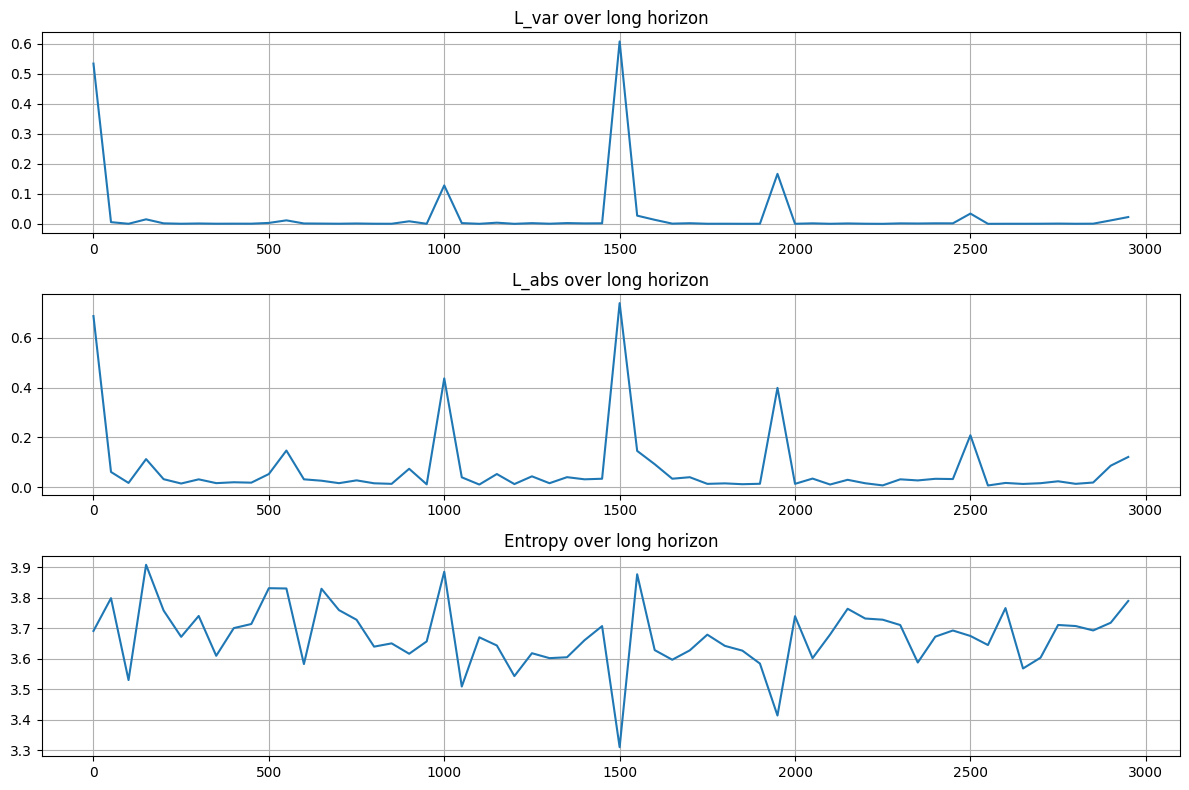

Final L_var: 0.022680163920159
Final L_abs: 0.12177644336740875
Final entropy: 3.7897849686657947


In [30]:
# ============================================================
#  LONG-HORIZON PHASE STRUCTURE (2000–5000 steps)
# ============================================================

def long_phase_test(state, steps=3000, sample_every=50):
    x = state.copy()
    L_var_vals = []
    L_abs_vals = []
    H_vals = []
    times = []

    for t in range(steps):
        # standard AC-CR operator mix
        op = random.choice([
            op_LC,
            op_SP,
            op_BP,
            lambda x: TAP(x, k=0.10, drift=0.0, noise_sigma=0.02, w=0.25)
        ])
        x = op(x)

        if t % sample_every == 0:
            L_var_vals.append(np.var(x))
            L_abs_vals.append(np.mean(np.abs(x)))
            H_vals.append(estimate_entropy(x))
            times.append(t)

    return np.array(times), np.array(L_var_vals), np.array(L_abs_vals), np.array(H_vals)


# --- run the long-horizon test ---
start = np.random.uniform(-1, 1, size=1024)
times, L_var_vals, L_abs_vals, H_vals = long_phase_test(start, steps=3000, sample_every=50)

# --- plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(times, L_var_vals)
plt.title("L_var over long horizon")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(times, L_abs_vals)
plt.title("L_abs over long horizon")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(times, H_vals)
plt.title("Entropy over long horizon")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Final L_var:", L_var_vals[-1])
print("Final L_abs:", L_abs_vals[-1])
print("Final entropy:", H_vals[-1])
